# Purpose
to ingest Sarah's skokholm data and start plotting! then to answer some basic questions about how mice move and maybe survive


Info from readme in folder:
There are three key logger data files produced using the code outlined in 'logger_data_organization.Rmd'. These represent a kind of 'checkpoint' for processing of the logger data.

1. all-logger-reads_20240821.rds: This is a dataframe that contains all of the logger pings, regardless of whether it recorded a PIT tag. No cleaning or corrections have been made, this dataset simply represents a concatenation of all of the logger entries.

2. PIT-tag-reads_20240821.rds: This data file now also contains metadata as to the location of loggers. Some cleaning has been performed to remove 'reads' that lack date/time information. This data file also only includes logger observations that correspond to PIT tag reads.

3. capture-data-matched-tag-reads_20240821.rds: This data file is the same as above, but retains only PIT reads that match to metadata entries in the capture data. The unclean file above contains a lot of erroneous reads like "X041A\x9f\xe8C5FB"

The second RMD, "skokholm_SRI-estimates_20240821.Rmd", contains code (repurposed from Aura's scripts) to build a social network. It will use the "capture-data-matched-tag-reads_20240821.rds" file as the input (quality controlled PIT tag reads with matched location and time/date data). Ultimately, you will need to decide whether to use only a subset of the data (when many loggers are active) or all of the data. Similarly, a key parameter to decide, is the degree of temporal overlap required for any two individuals to be considered 'associated'. This parameter can be specified on the second line of code in the "B) CONSTRUCTING the GBI and GD matrices...." section. 

Capture metadata files and logger location files were acquired from the lab google drive. 

# imports

In [2]:
import pandas as pd
import numpy as np 
import math, os, sys
import matplotlib.pyplot as plt 
from haversine import haversine, Unit

# load data

In [3]:
os.listdir('../../../skok25/skok_logger')

['all-logger-reads_20240821.csv',
 'all-logger-reads_20240821.rds',
 'capture-data-matched-tag-reads_20240821.csv',
 'capture-data-matched-tag-reads_20240821.rds',
 'logger_data_organization.Rmd',
 'logger_locations.csv',
 'Logger_locations_across_all_trips.csv',
 'PIT-tag-reads_20240821.csv',
 'PIT-tag-reads_20240821.rds',
 'plots',
 'README.txt',
 'Sep22Apr23_loggers',
 'sept2022apr2023loggers',
 'skokholm_SRI-estimates_20240821.Rmd',
 'skok_capture_2024-05-21.csv',
 'skok_logger_organization_sri_20240821']

In [4]:
capture_data = pd.read_csv('/Users/dennise/Desktop/skok25/skok_logger/skok_capture_2024-05-21.csv')
# there are over a thousand columns and many are interesting! (date, external sex, pregnancy, length, etc)
# for now I just want the animal_ID, PIT_tag, PIT_detected, PIT_tagging_occurred, trap_number, flag, location, location notes, site, collection date, unique_ID, identifier, X, released, PIT_tagging_comments, trapping_date, Garmin_GPS, PIT_tag_nonmod, mouse_id, trap_penuts, trap_comments, datetrap, Year, Month, Day, year_month, latitude, longitude
subcapture = capture_data[['identifier', 'X','unique_id','animal_ID', 'PIT_tag', 'PIT_detected', 'PIT_tagging_occurred', 'trap_number', 'flag', 'location', 'location_notes', 'site', 'collection_date', 'released', 'PIT_tagging_comments', 'trapping_date', 'Garmin_GPS', 'PIT_tag_nonmod', 'mouse_id', 'trap_peanuts', 'trap_comments', 'datetrap', 'Year', 'Month', 'Day', 'year_month', 'latitude', 'longitude']]
subcapture=subcapture.replace(to_replace=np.nan,value='nan') # lots of mixed types
#subcapture[subcapture.PIT_tag=='nan'].to_csv('/Users/dennise/Desktop/subcapture_nan_PITtags.csv') # want to nans which include escapes,pregnant lactating, too young, etc
subcapture=subcapture[subcapture.PIT_tag!='nan'].reset_index(drop=True)


In [ ]:
mergeddf = pd.read_csv("/Users/dennise/Desktop/skok25/skok_logger/capture-data-matched-tag-reads_20240821.csv",index_col=0)
mergeddf.columns=['PIT_tagX', 'location_found_cleaned', 'logger_id_season', 'datetime',
       'LOGGER_ID', 'WIRELESS_ID', 'motion_det', 'tempC', 'hum.', 'AMP1ADC',
       'AMP2ADC', 'batV_L', 'batV_NL', 'int.tempC', 'PIT_tag', 'Err', 'Line',
       'Pdir', 'ext.tempC', 'Comment', 'Day', 'Month', 'Yearx', 'Hours',
       'Minutes', 'Seconds', 'logger_season', 'logger_id', 'location_found',
       'trip', 'Yeary', 'Trapping_date', 'collection_date', 'Season',
       'Trapping_site', 'Trapping_point', 'Garmin_GPS', 'Garmin_ID',
       'latitude', 'longitude', 'No_trappingpoints', 'Comments',
       'Merge_GPS_coordinates_by', 'unique_flag_location', 'datetime2',
       'time_difference', 'preceding_same', 'first_value', 'winter_interval',
       'date_actual', 'date', 'mouse_ID', 'PIT_tag', 'dummy']

C:\Users\dennise\AppData\Local\Temp\ipykernel_27000\2190805515.py:1: DtypeWarning: Columns (8,47) have mixed types. Specify dtype option on import or set low_memory=False.
  capturereads = pd.read_csv("/Users/dennise/Desktop/skok25/skok_logger/capture-data-matched-tag-reads_20240821.csv",index_col=0)


In [6]:
capturereads=capturereads.sort_values(by='date_actual')
capturereads['yearmonth'] = capturereads.Yearx + (capturereads.Month/13)

In [7]:
nights=list(capturereads.Day)
capturereads=capturereads.reset_index(drop=True)
for idx in capturereads.index:
    if capturereads.Hours[idx] < 8:
        print(idx)
        nights[idx]+=-1
capturereads['night']=nights
capturereads.night+=1



0
1
2
7
66
74
82
85
90
99
100
101
104
110
111
112
113
115
120
122
124
128
130
139
155
156
158
162
163
179
181
182
186
187
189
190
191
192
193
194
195
196
197
198
200
201
202
203
205
206
207
208
209
210
211
219
220
223
225
227
230
233
235
241
243
247
248
249
250
251
255
264
314
315
316
317
318
319
320
321
323
324
325
326
327
328
329
330
331
333
334
337
338
340
342
344
346
347
348
351
354
357
374
381
382
383
384
385
386
389
392
395
396
398
399
400
401
402
423
425
448
451
452
456
457
458
459
460
461
462
463
466
467
471
472
480
482
484
494
497
499
500
501
502
504
505
506
507
508
509
510
511
512
514
515
516
517
518
519
520
527
534
535
537
539
542
548
554
556
566
570
572
577
578
580
602
604
606
607
608
616
622
623
624
629
630
635
638
642
644
651
654
656
657
658
659
661
662
689
691
713
715
716
725
727
730
731
732
733
735
748
749
753
754
755
756
757
758
759
760
761
762
763
764
765
766
773
774
776
777
778
779
780
782
802
810
815
816
817
819
825
830
831
833
834
835
836
837
838
839
840
841
842
84

In [8]:
capturereads['nightstr']="20"+capturereads.Yearx.astype(str)+"-"+capturereads.Month.apply(lambda x: f"{x:02d}")+"-"+capturereads.night.apply(lambda x: f"{x:02d}")

capturereads.nightstr

0        2020-09-07
1        2020-09-07
2        2020-09-07
3        2020-09-09
4        2020-09-09
            ...    
25224    2023-04-31
25225    2023-04-31
25226    2023-04-31
25227    2023-04-30
25228    2023-05-02
Name: nightstr, Length: 25229, dtype: object

# merging captures and capture_reads

PIT_tag object object
LOGGER_ID object object
night int64 int64
nightstr object object
latitude float64 float64
longitude float64 float64
Year int64 int64
Month int64 int64
Day int64 int64
Minute float64 float64


C:\Users\dennise\AppData\Local\Temp\ipykernel_27000\627831409.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  readsformerge[['Year','Month','Day']] = readsformerge.date_actual.str.split('-',expand=True)
C:\Users\dennise\AppData\Local\Temp\ipykernel_27000\627831409.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  readsformerge[['Year','Month','Day']] = readsformerge.date_actual.str.split('-',expand=True)
C:\Users\dennise\AppData\Local\Temp\ipykernel_27000\627831409.py:4: SettingWithCopyWarning: 
A val

(51.69, 51.705)

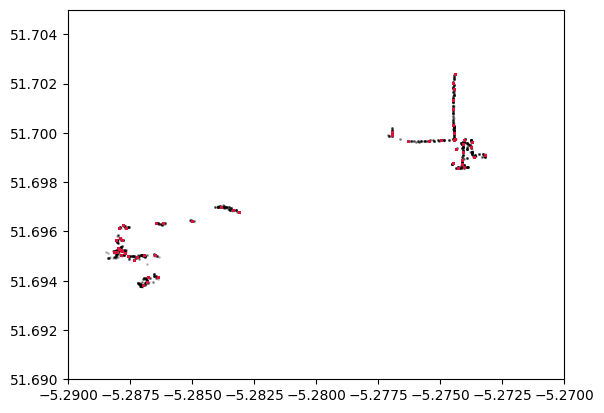

In [131]:
readsformerge=capturereads[['mouse_ID','LOGGER_ID','datetime','date_actual','date','yearmonth','night','nightstr','GPS_latitude','GPS_longitude']]
readsformerge.columns=['PIT_tag','LOGGER_ID','datetime','date_actual','date','yearmonth','night','nightstr','latitude','longitude']
readsformerge # want Year, Month, Day + night, nightstr, PIT_tag, LOGGER_ID, lat, long
readsformerge[['Year','Month','Day']] = readsformerge.date_actual.str.split('-',expand=True)

timedf = readsformerge.datetime.str.split(' ',expand=True)[1].str.split(':',expand=True).astype(int)
timedf.columns=['hours','minutes','seconds']
readsformerge['Minute']=(timedf.hours*60)+timedf.minutes+(timedf.seconds/60)
readsformerge=readsformerge.drop(columns=['datetime','date_actual','date','yearmonth'])
readsformerge.columns
captureformerge = subcapture[['PIT_tag','Year','Month','Day','latitude','longitude']].copy()
captureformerge['night']=captureformerge.Day-1
captureformerge['LOGGER_ID']='0000'
captureformerge['nightstr']=captureformerge.Year.astype(str)+'-'+captureformerge.Month.apply(lambda x: f"{x:02d}")+'-'+captureformerge.night.apply(lambda x: f"{x:02d}")
captureformerge['Minute']=-1.
captureformerge.columns
captureformerge.latitude=captureformerge.latitude.astype(float)
captureformerge.longitude=captureformerge.longitude.astype(float)

readsformerge.Year=readsformerge.Year.astype(int)
readsformerge.Month=readsformerge.Month.astype(int)
readsformerge.Day=readsformerge.Day.astype(int)
for colval in readsformerge.columns:
    print(colval,readsformerge[colval].dtype,captureformerge[colval].dtype) # make sure cols have same dtype
readsformerge=readsformerge[list(captureformerge)] # make sure cols are in same order
mergeddf=pd.concat([readsformerge,captureformerge]).reset_index(drop=True)
plt.scatter(mergeddf.longitude,mergeddf.latitude,alpha=0.2,c='k',s=1)
plt.scatter(capturereads.GPS_longitude,capturereads.GPS_latitude, s=1,c='crimson')
plt.xlim(-5.29,-5.27)
plt.ylim(51.69,51.705)
#plt.savefig('/Users/dennise/Desktop/skok25/skok_logger/plots/locations_all_redloggers.eps', bbox_inches='tight')

# Procedure

In [132]:
mergeddf

,PIT_tag,Year,Month,Day,latitude,longitude,night,LOGGER_ID,nightstr,Minute
0,X041A1F3790_X041A1F2DB5,2020,9,7,51.699732,-5.274423,7,0843,2020-09-07,219.700000
1,X041A1F3689_X041A1F2D75_X041A1F3212,2020,9,7,51.699732,-5.274423,7,0843,2020-09-07,289.050000
2,X041A1F3689_X041A1F2D75_X041A1F3212,2020,9,7,51.699732,-5.274423,7,0843,2020-09-07,288.933333
3,X041A1F3790_X041A1F2DB5,2020,9,8,51.699732,-5.274423,9,0843,2020-09-09,1186.716667
4,X041A1F282F_X041A1F3271,2020,9,8,51.699732,-5.274423,9,0843,2020-09-09,888.950000
...,...,...,...,...,...,...,...,...,...,...
26952,X041918113E,2019,7,19,51.695598,-5.288075,18,0000,2019-07-18,-1.000000
26953,X041A5571C5_X041A556889_X0419181D4A,2019,7,20,51.693820,-5.287067,19,0000,2019-07-19,-1.000000
26954,X041A5571F8_X041A5571F8,2019,7,19,51.693948,-5.286606,18,0000,2019-07-18,-1.000000
26955,X0XXXXXXXX2,2019,7,15,51.699636,-5.274008,14,0000,2019-07-14,-1.000000


In [133]:
print(len(np.unique(mergeddf.PIT_tag)))

715


In [134]:
print(np.min(mergeddf.latitude), np.max(mergeddf.latitude))
print(np.min(mergeddf.longitude), np.max(mergeddf.longitude))

minlat=np.min(mergeddf.latitude)
minlong=np.min(mergeddf.longitude)
arbit_dist=[]

for idx in mergeddf.index:
    lat=mergeddf.loc[idx,'latitude']
    long=mergeddf.loc[idx,'longitude']
    arbit_dist.append(haversine((minlat,minlong),(lat,long)))
mergeddf['arbit_dist']=arbit_dist

51.69375996 51.70237396
-5.288477987 -5.273205992


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


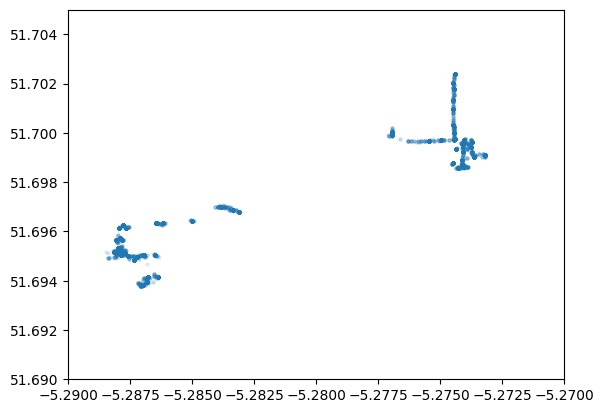

In [135]:
plt.scatter(mergeddf.longitude,mergeddf.latitude, s=5, alpha=0.1)
plt.xlim(-5.29,-5.27)
plt.ylim(51.69,51.705)
plt.savefig('/Users/dennise/Desktop/skok25/skok_logger/plots/locations_all.eps', bbox_inches='tight')

In [136]:
print(len(np.unique(mergeddf.PIT_tag)))
print(mergeddf.columns)

715
Index(['PIT_tag', 'Year', 'Month', 'Day', 'latitude', 'longitude', 'night',
       'LOGGER_ID', 'nightstr', 'Minute', 'arbit_dist'],
      dtype='object')


In [137]:
survivors = []
migrants=[]

for tag in np.unique(mergeddf.PIT_tag):
    # if mergeddf.longitude > 5.28 and < 5.28 they've been near obs/near quarry
    if len(np.unique(mergeddf[mergeddf.PIT_tag == tag].Year))>1:
        survivors.append(tag)
    tempdf = mergeddf[mergeddf.PIT_tag == tag]
    if tempdf.longitude.max() > -5.28 and tempdf.longitude.min() < -5.28:
        migrants.append(tag)
print('migrants: ', len(migrants),'survivors: ',len(survivors))

migrants:  12 survivors:  59


In [138]:
migrants

['X041917E55B',
 'X041918200B',
 'X04191827D8',
 'X0419182A44',
 'X041918331E',
 'X041A1F21E6_X041A1F2404',
 'X041A1F2373',
 'X041A1F2EEA',
 'X041A1F4430',
 'X041ABBC014',
 'X041ABBC8F7_X041ABBAC42',
 'X041ABBC9CC']

31 28


Text(0.5, 1.0, 'NOTE this is only looking at the **first** place this mouse was seen \n does not include over-wintering location, \n need a more nuanced approach')

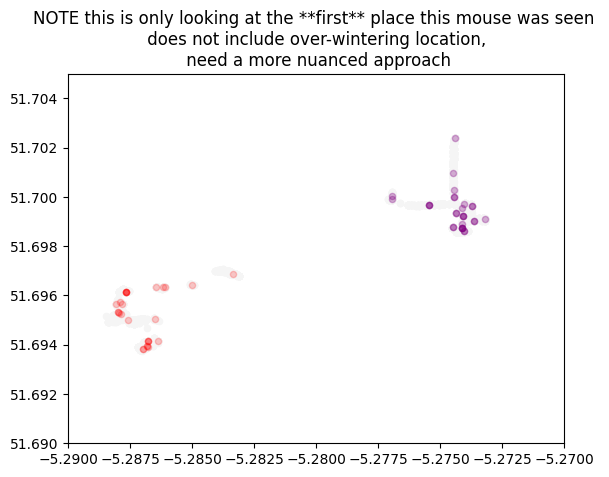

In [139]:
obssurv=0
quarrysurv=0
survlist=[]
fig,ax=plt.subplots(1,1)
ax.scatter(mergeddf.longitude,mergeddf.latitude , s=20, c='whitesmoke')
ax.set_xlim(-5.29,-5.27)
ax.set_ylim(51.69,51.705)
for survivor in survivors: 
    if list(mergeddf.longitude[mergeddf.PIT_tag == survivor])[0] > -5.280:
        plt.scatter(list(mergeddf.longitude[mergeddf.PIT_tag == survivor])[0],list(mergeddf.latitude[mergeddf.PIT_tag == survivor])[0], c='purple',alpha=0.3,s=20)
        obssurv+=1
        survlist.append(0)
    else:
        quarrysurv+=1
        survlist.append(1) 
        plt.scatter(list(mergeddf.longitude[mergeddf.PIT_tag == survivor])[0],list(mergeddf.latitude[mergeddf.PIT_tag == survivor])[0], c='r',alpha=0.2,s=20)
print(obssurv, quarrysurv)
ax.set_title('NOTE this is only looking at the **first** place this mouse was seen \n does not include over-wintering location, \n need a more nuanced approach')
#ax.set_facecolor('black')
# specifically should get most wintery location I think... but knowing that at least a few migrate


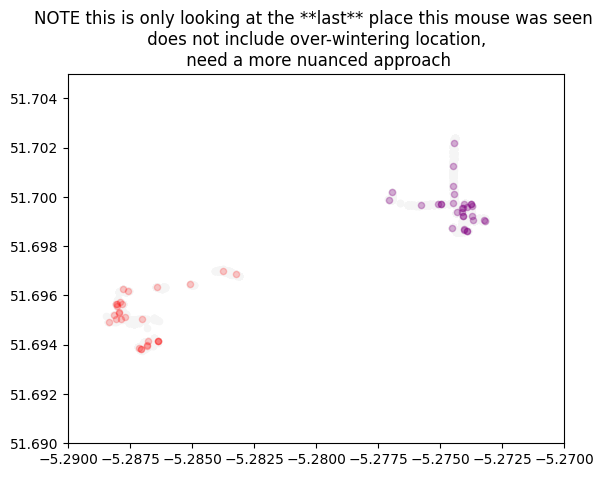

31 28


In [140]:
obssurv_end=0
quarrysurv_end=0
survlist_end=[]
plt.scatter(mergeddf.longitude,mergeddf.latitude , s=20, c='whitesmoke')
for survivor in survivors: 
    if list(mergeddf.longitude[mergeddf.PIT_tag == survivor])[0] > -5.280:
        plt.scatter(list(mergeddf.longitude[mergeddf.PIT_tag == survivor])[-1],list(mergeddf.latitude[mergeddf.PIT_tag == survivor])[-1], c='purple',alpha=0.3,s=20)
        obssurv_end+=1
        survlist_end.append(0)
    else:
        quarrysurv_end+=1
        survlist_end.append(1) 
        plt.scatter(list(mergeddf.longitude[mergeddf.PIT_tag == survivor])[-1],list(mergeddf.latitude[mergeddf.PIT_tag == survivor])[-1], c='r',alpha=0.2,s=20)
plt.xlim(-5.29,-5.27)
plt.ylim(51.69,51.705)
plt.title('NOTE this is only looking at the **last** place this mouse was seen \n does not include over-wintering location, \n need a more nuanced approach')
plt.show()
print(obssurv_end,quarrysurv_end)
# specifically should get most wintery location I think... but knowing that at least a few migrate


In [141]:
migrants #check 041abbc507, 041abbcb40

['X041917E55B',
 'X041918200B',
 'X04191827D8',
 'X0419182A44',
 'X041918331E',
 'X041A1F21E6_X041A1F2404',
 'X041A1F2373',
 'X041A1F2EEA',
 'X041A1F4430',
 'X041ABBC014',
 'X041ABBC8F7_X041ABBAC42',
 'X041ABBC9CC']

In [142]:
mergeddf.columns

Index(['PIT_tag', 'Year', 'Month', 'Day', 'latitude', 'longitude', 'night',
       'LOGGER_ID', 'nightstr', 'Minute', 'arbit_dist'],
      dtype='object')

In [143]:

for migrant in migrants:
    plt.scatter(mergeddf.longitude,mergeddf.latitude , s=5, c='whitesmoke')
    plt.scatter(mergeddf.longitude[mergeddf.PIT_tag == migrant],mergeddf.latitude[mergeddf.PIT_tag == migrant], s=10, c = mergeddf.Year[mergeddf.PIT_tag == migrant])
    plt.clim(2020,2024)
    plt.colorbar()
    plt.xlim(-5.29,-5.27)
    plt.ylim(51.69,51.705)
    plt.savefig('/Users/dennise/Desktop/skok25/skok_logger/plots/__migrant_locations_{}.png'.format(migrant), bbox_inches='tight')
    plt.close()


In [144]:
for migrant in migrants:
    print(migrant,np.min(mergeddf.Year[mergeddf.PIT_tag == migrant]), np.max(mergeddf.Year[mergeddf.PIT_tag == migrant]))

X041917E55B 2019 2019
X041918200B 2019 2019
X04191827D8 2019 2019
X0419182A44 2019 2019
X041918331E 2019 2019
X041A1F21E6_X041A1F2404 2020 2020
X041A1F2373 2021 2021
X041A1F2EEA 2021 2022
X041A1F4430 2021 2021
X041ABBC014 2022 2022
X041ABBC8F7_X041ABBAC42 2022 2023
X041ABBC9CC 2022 2022


In [145]:
for migrant in migrants:
    print(' ON MIGRANT {}'.format(migrant))
    print(mergeddf[mergeddf.PIT_tag==migrant].sort_values(['Year','Month','Day'])['longitude'])

 ON MIGRANT X041917E55B
25248   -5.273742
25249   -5.274111
25472   -5.274073
25473   -5.285094
Name: longitude, dtype: float64
 ON MIGRANT X041918200B
25586   -5.286725
25587   -5.286725
25585   -5.274045
Name: longitude, dtype: float64
 ON MIGRANT X04191827D8
25605   -5.286913
25604   -5.287175
25603   -5.274427
Name: longitude, dtype: float64
 ON MIGRANT X0419182A44
25297   -5.283532
25612   -5.284069
25613   -5.274470
Name: longitude, dtype: float64
 ON MIGRANT X041918331E
25307   -5.283744
25636   -5.273928
25447   -5.274095
Name: longitude, dtype: float64
 ON MIGRANT X041A1F21E6_X041A1F2404
25720   -5.273740
25761   -5.287960
25759   -5.287935
25760   -5.287888
25763   -5.288065
           ...   
1007    -5.288155
1038    -5.288155
1071    -5.288155
1087    -5.288155
1089    -5.288155
Name: longitude, Length: 66, dtype: float64
 ON MIGRANT X041A1F2373
25747   -5.274164
5382    -5.274126
5392    -5.274126
5430    -5.274126
5433    -5.274126
7480    -5.274126
7483    -5.274126
7501

In [ ]:

for tag in np.unique(mergeddf.PIT_tag):
    if tag not in survivors:
        plt.scatter(mergeddf.latitude,mergeddf.longitude , s=10, c='whitesmoke')
        plt.scatter(mergeddf.latitude[mergeddf.PIT_tag == tag],mergeddf.longitude[mergeddf.PIT_tag == tag] , s=20,c=mergeddf.Year[mergeddf.PIT_tag == tag]+(mergeddf.Month[mergeddf.PIT_tag == tag]/13),cmap='plasma')
        plt.colorbar()
        plt.ylim(-5.29,-5.27)
        plt.xlim(51.69,51.705)
        plt.clim(20,23)
        plt.savefig('/Users/dennise/Desktop/skok25/skok_logger/plots/locations_'+tag+'.png', dpi=300, bbox_inches='tight')
        plt.close()


In [ ]:
# how many first have a Year <2023?
numval=0
lastyear=0
for tag in np.unique(mergeddf.PIT_tag):
    if np.min(mergeddf.Year[mergeddf.PIT_tag==tag])<2023:
        numval+=1
    else:
        lastyear+=1
print(numval, lastyear, len(np.unique(mergeddf.PIT_tag)))

# how many in obs and quarry? count migrants 2x
quarry=0
obs=0
for tag in np.unique(mergeddf.PIT_tag):
    if np.min(mergeddf.longitude[mergeddf.PIT_tag==tag])<-5.28:
        quarry+=1
    if np.max(mergeddf.longitude[mergeddf.PIT_tag==tag])>-5.28:
        obs+=1
print(quarry, obs, len(np.unique(mergeddf.PIT_tag)))

670 45 715
340 382 715


# want to calculate a bunch of stuff, dropping ideas here for now:
-  distance (max) for each mouse
- for each night, what's the # of mice seen? are there good nights/bad nights? can we see die-off with these data?
- for each mouse, how often do we expect to see them consecutively?
- what is a normal range for a mouse per night? week? month? season?
- questions about the data: 
    - do we have the capture data or just pit tags here? seems like just pit tags, but the capture data should be in this folder somewhere... need to dig back into the readme/rmd files since they explain where the data came from and how it was pruned. 
    - what about mice assigned multiple RFIDs or lost RFIDs? are they showing up as different mice or same mouse?
- there seem to be three mice who have traversed the island, one of them twice!! this implies migration is more rare then we thought... 
- there seem to be 49 survivors...

### max distance travelled for each mouse

In [ ]:
# distance (max) for each mouse, I guess start in GPS long/lat
check_in_nos=[]
max_dists=[]
for mouse in np.unique(mergeddf.PIT_tag):
  mousedf=mergeddf[mergeddf.PIT_tag==mouse].reset_index(drop=True)
  check_in_nos.append(len(mousedf))
  unique_lats = np.unique(mousedf.latitude)
  dists=[]
  # for each unique_reader for this mouse, get the distance between the readers
  
  for lat_a in unique_lats:
    if not np.isnan(lat_a):
      long_a=np.unique(mousedf.loc[lambda mousedf: mousedf.latitude==lat_a, lambda df: ['longitude']])[0]
    for lat_b in unique_lats:
      if not np.isnan(lat_b):
        long_b=np.unique(mousedf.loc[lambda mousedf: mousedf.latitude==lat_b, lambda df: ['longitude']])[0]
        dists.append(haversine((lat_a,long_a),(lat_b,long_b),unit=Unit.METERS))
  if len(dists)<1:
    max_dists.append(np.nan)
  else:
    max_dists.append(np.max(dists))


X041917E004
X041917E031
X041917E04E
X041917E062
X041917E15B
X041917E1B8
X041917E205
X041917E211_X041917E63B
X041917E25D
X041917E2C4
X041917E386
X041917E38A
X041917E45E
X041917E548
X041917E55B
X041917E6C9
X041917E731
X041917E7BD
X041917E9C7
X041917E9C8
X041917E9D6
X041917E9DB
X041917EAEC_X041917FE84
X041917ECA9
X041917ECB4
X041917EE77
X041917EE7F
X041917F050
X041917F05F
X041917F0FF
X041917F18B
X041917F18E
X041917F196
X041917F237
X041917F2E8
X041917F4E3
X041917F581
X041917F6DD
X041917F791
X041917F8E5
X041917F99D
X041917FA51
X041917FB00_X041A1F32B8
X041917FB03
X041917FBAD
X041917FD16
X041917FE81
X041917FF41
X041917FF44
X04191800AB
X04191800B1
X0419180171
X0419180216
X04191802D3_X0419183575
X04191802DA
X04191802E4
X04191804FD
X0419180676
X04191807F6
X04191808AC
X041918095E
X0419180962
X0419180967
X0419180AC6
X0419180AD8
X0419180C34
X0419180E61
X0419180E65
X0419180E69
X0419180F14
X0419180FC5
X0419180FC6
X041918107D
X0419181086
X041918113E
X041918129F
X041918134C
X0419181400
X04191814C6
X041

In [ ]:
mouse_stat_df=pd.DataFrame(columns=['mouse','max_dists','no_checkins'])
mouse_stat_df.max_dists=max_dists 
mouse_stat_df.no_checkins = check_in_nos
mouse_stat_df.mouse = np.unique(mergeddf.PIT_tag)
travelers = mouse_stat_df.index[mouse_stat_df.max_dists>200]
print(travelers)
print(len(travelers))

Index([ 14,  42,  95, 106, 111, 112, 130, 165, 177, 219, 254, 280, 306, 325,
       366, 387, 393, 454, 472, 474, 479, 501, 502, 510, 642, 671, 679, 687,
       701, 704, 705, 709],
      dtype='int64')
32


## TODO 
probably can use the above structure to get all distances based on the arbit_dist... by night seems like a doable stat (if seen at all, get a distance) but would want NIGHTS not dates which is... annoying

In [ ]:
x=9
print(len(mouse_stat_df[mouse_stat_df.no_checkins>x])/len(mouse_stat_df))
print(mouse_stat_df.columns)

0.3594405594405594
Index(['mouse', 'max_dists', 'no_checkins'], dtype='object')


# TODO should prob fix nights==0, but for now...

In [ ]:
# want dist travelled each night
# get all mice with 10+ checkins

# set up empty variables
all_mice=[]
num_loggers=[]
logger_list=[]
GPS_lats=[]
GPS_longs=[]
no_checkins = []
max_dists=[]
nights=[]
for mouse in list(mouse_stat_df.mouse[mouse_stat_df.no_checkins>8]):
    # get just this mouse's info
    subdf = mergeddf[mergeddf.PIT_tag==mouse]
    # set up empty variables
    # get all unique nights
    mousenights=np.unique(subdf.nightstr)
    for night in mousenights:
        # for each night, get loggers
        loggers=np.unique(subdf.LOGGER_ID[subdf.nightstr==night])
        distlist=[]
        mouselats =[]
        mouselongs=[]
        for logger in loggers:
            nights.append(night)
            all_mice.append(mouse)
            logger_list.append(logger)
            num_loggers.append(len(loggers))
            subsubdf = subdf[(subdf.nightstr==night) & (subdf.LOGGER_ID==logger)]
            no_checkins.append(len(subsubdf))
            curr_lat=list(subsubdf.latitude)[0]
            curr_long=list(subsubdf.longitude)[0]
            GPS_lats.append(curr_lat)
            mouselats.append(curr_lat)
            GPS_longs.append(curr_long)
            mouselongs.append(curr_long)
        for logger in loggers:
            for idx in np.arange(0,len(loggers)):
                distlist.append(haversine((curr_lat,curr_long),(mouselats[idx],mouselongs[idx]),unit=Unit.METERS)) #lat then lon
            max_dists.append(np.max(distlist))
mouse_night_df = pd.DataFrame(columns=['mouse','nightstr','num_loggers','loggers','GPS_lats','GPS_longs','no_checkins','max_dists'])
mouse_night_df.nightstr = nights
mouse_night_df.mouse = all_mice
mouse_night_df.num_loggers = num_loggers
mouse_night_df.loggers = logger_list
mouse_night_df.GPS_lats = GPS_lats
mouse_night_df.GPS_longs = GPS_longs
mouse_night_df.no_checkins = no_checkins
mouse_night_df.max_dists = max_dists


In [ ]:
mouse_night_df.sort_values(by='nightstr')

,mouse,nightstr,num_loggers,loggers,GPS_lats,GPS_longs,no_checkins,max_dists
2363,X041A1F3790_X041A1F2DB5,2020-09-07,1,0843,51.699732,-5.274423,1,0.0
2291,X041A1F3689_X041A1F2D75_X041A1F3212,2020-09-07,1,0843,51.699732,-5.274423,2,0.0
2364,X041A1F3790_X041A1F2DB5,2020-09-08,1,0843,51.699732,-5.274423,1,0.0
2365,X041A1F3790_X041A1F2DB5,2020-09-09,1,0843,51.699732,-5.274423,8,0.0
593,X041A1F282F_X041A1F3271,2020-09-09,1,0843,51.699732,-5.274423,7,0.0
...,...,...,...,...,...,...,...,...
4763,X041ABBC94C,2023-5-2,1,0000,51.694991,-5.287368,1,0.0
3956,X041ABBA7F0,2023-5-2,1,0000,51.695034,-5.287753,1,0.0
4752,X041ABBC8F7_X041ABBAC42,2023-5-2,1,0000,51.694923,-5.287275,1,0.0
3836,X041ABBA017,2023-5-2,1,0000,51.696353,-5.286384,1,0.0


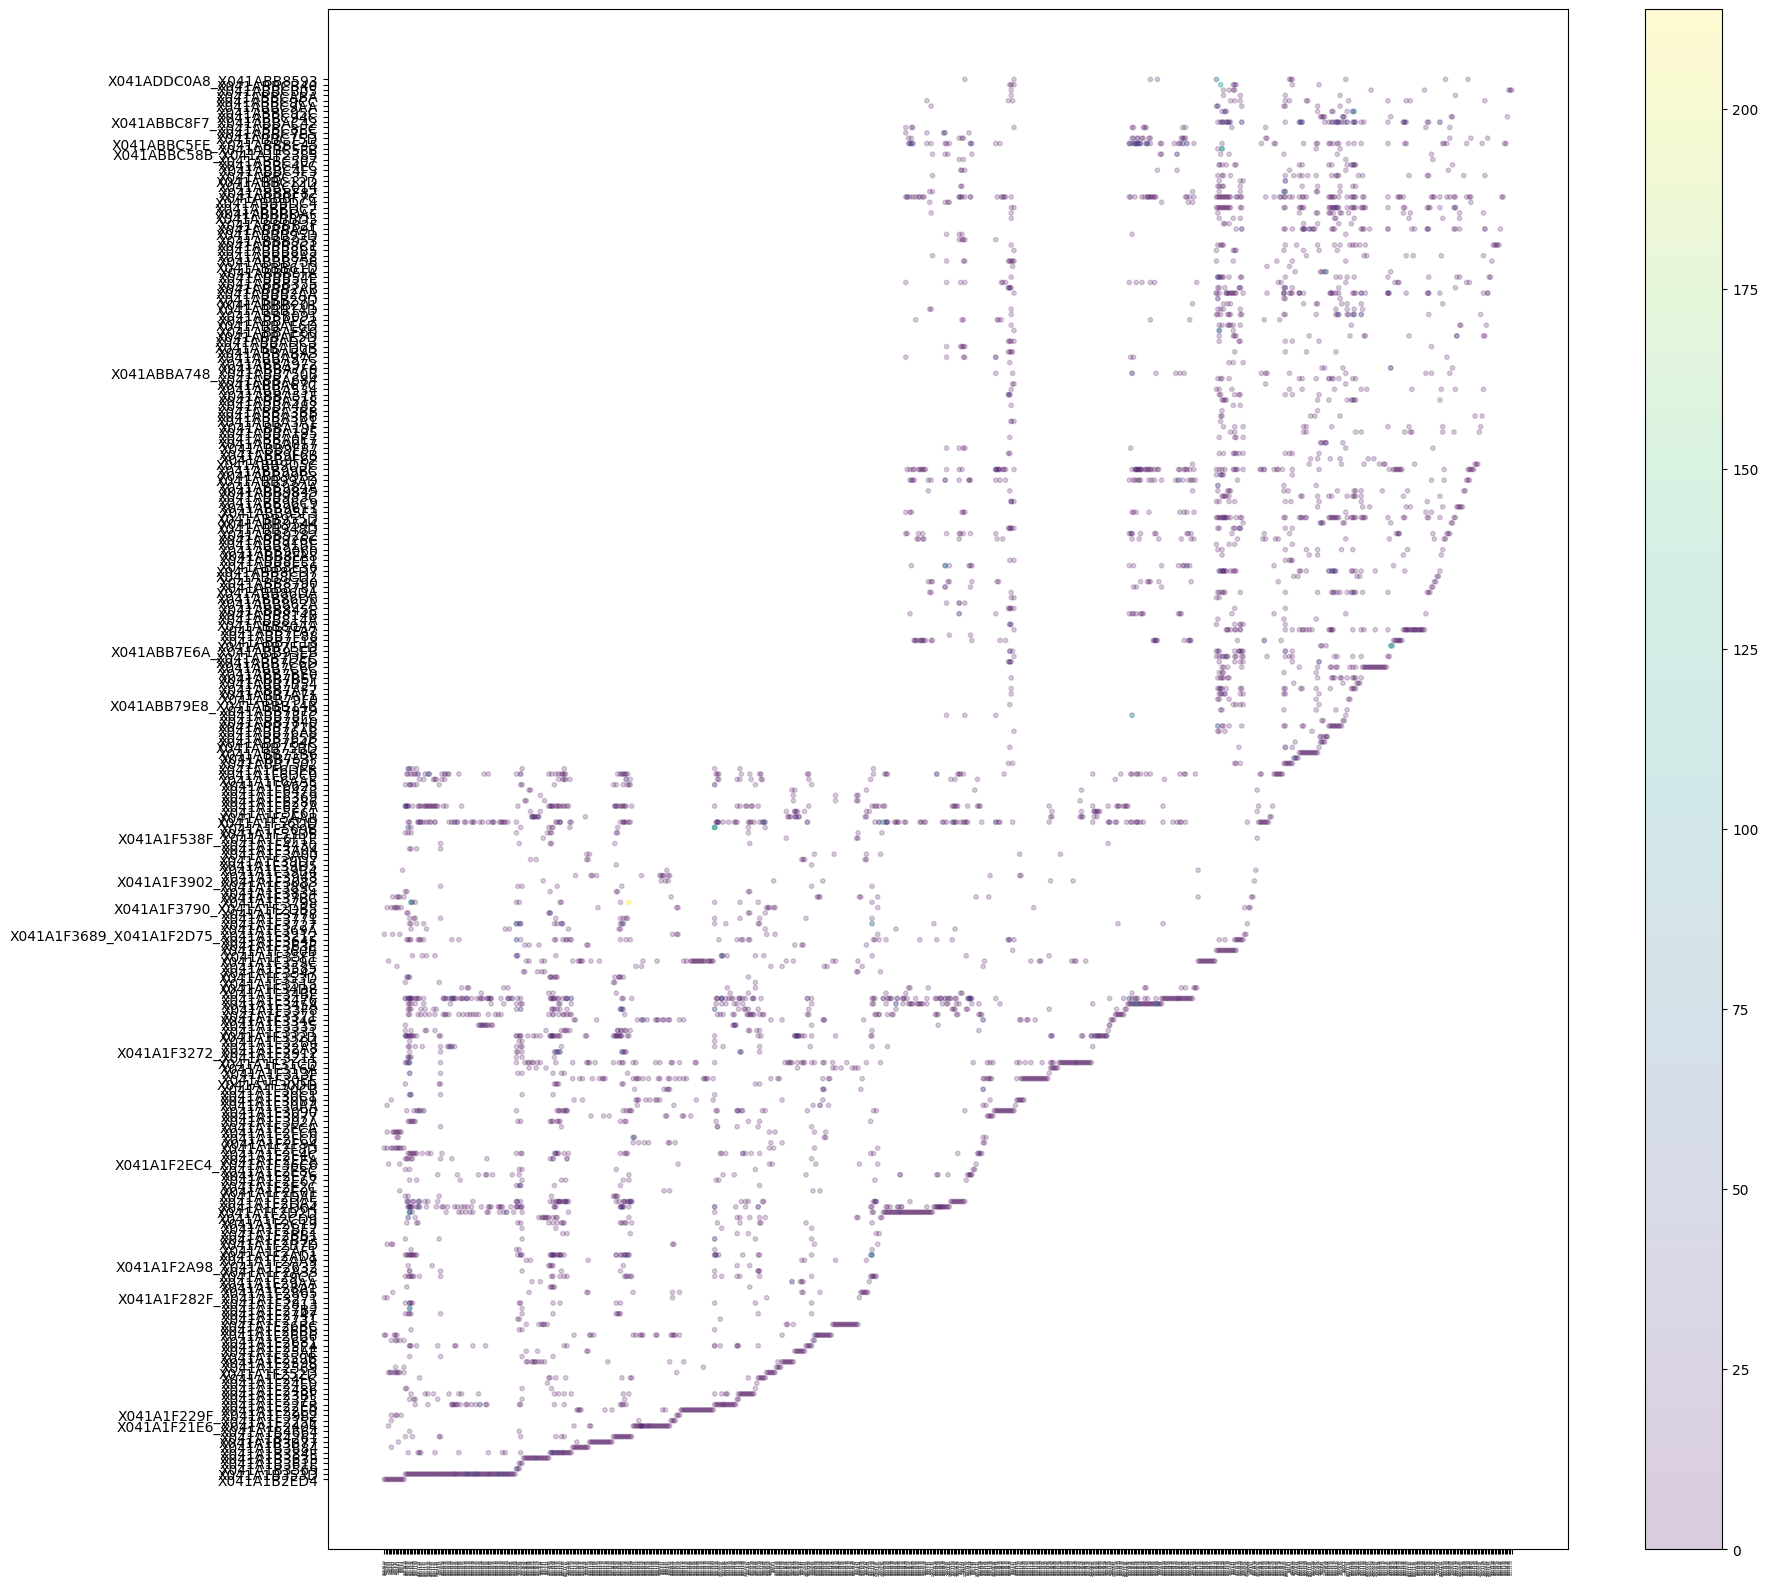

In [ ]:
plt.figure(figsize=(20,20))
plt.scatter(mouse_night_df.nightstr,mouse_night_df.mouse,s=10,alpha=0.2,c=mouse_night_df.max_dists)
plt.xticks(rotation=90,fontsize=2)
plt.colorbar(
)
plt.show()

In [ ]:
mouse_night_df=mouse_night_df.sort_values(by='nightstr')

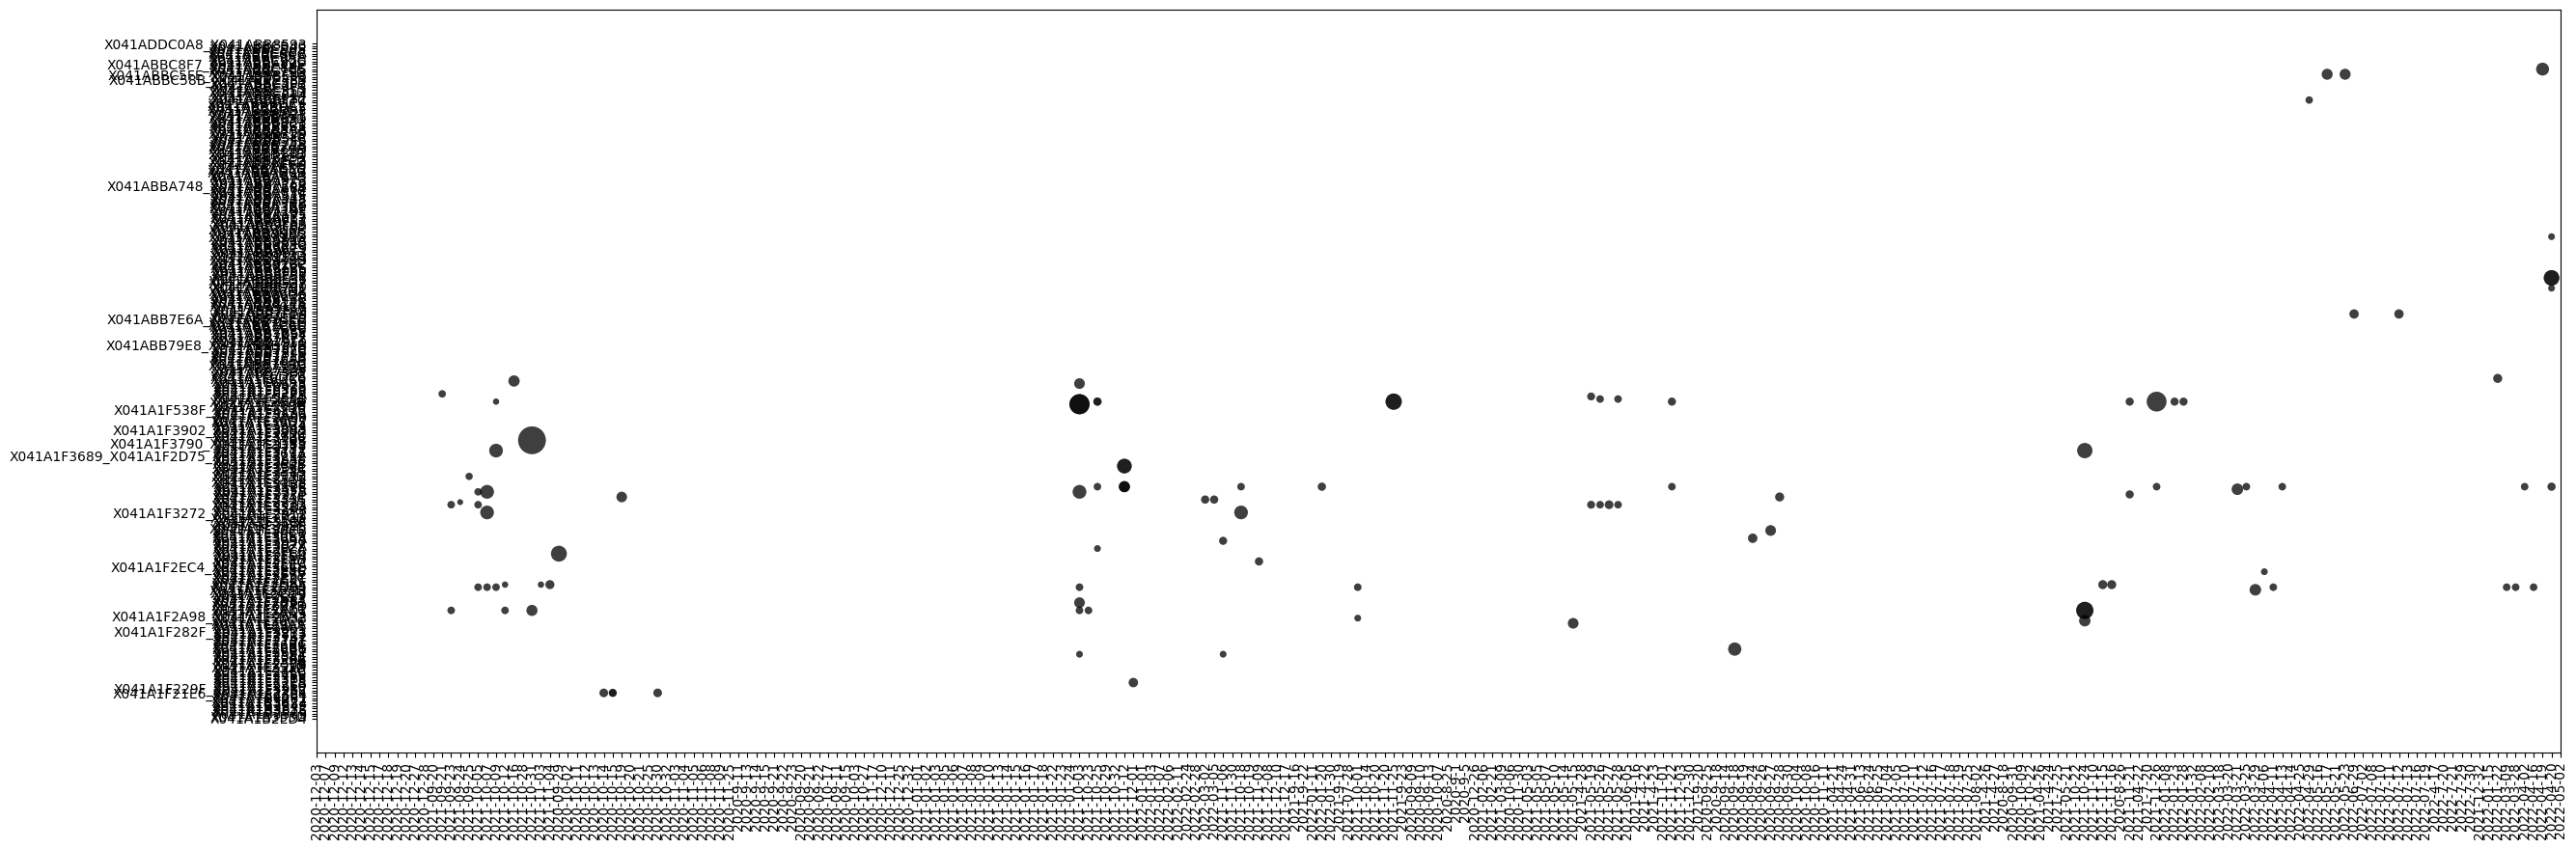

In [ ]:
plt.figure(figsize=(30,10))
plt.scatter(mouse_night_df.nightstr,mouse_night_df.mouse,c='k',alpha=0.5,s=2*mouse_night_df.max_dists,linewidth=0)
plt.xticks(rotation=90,fontsize=10)
plt.xlim(150,400)
plt.show()

In [ ]:
mouse_night_df

,mouse,nightstr,num_loggers,loggers,GPS_lats,GPS_longs,no_checkins,max_dists
1958,X041A1F3689_X041A1F2D75_X041A1F3212,2020-09-06,1,0843,51.699732,-5.274423,2,0.000000
2022,X041A1F3790_X041A1F2DB5,2020-09-06,1,0843,51.699732,-5.274423,1,0.000000
2023,X041A1F3790_X041A1F2DB5,2020-09-07,1,0843,51.699732,-5.274423,1,0.000000
357,X041A1F252D,2020-09-09,1,0843,51.699732,-5.274423,6,0.000000
492,X041A1F282F_X041A1F3271,2020-09-09,1,0843,51.699732,-5.274423,7,0.000000
...,...,...,...,...,...,...,...,...
4027,X041ABBC94C,2023-04-29,1,0816,51.695023,-5.287580,1,0.000000
2987,X041ABB9544,2023-04-30,1,080E,51.695251,-5.287888,27,0.000000
2705,X041ABB7EED,2023-04-31,2,080E,51.695251,-5.287888,2,98.565312
2706,X041ABB7EED,2023-04-31,2,0841,51.696126,-5.287659,1,98.565312


obs 0.0 20.396561498547847
quarry 0.0 31.277723341978863


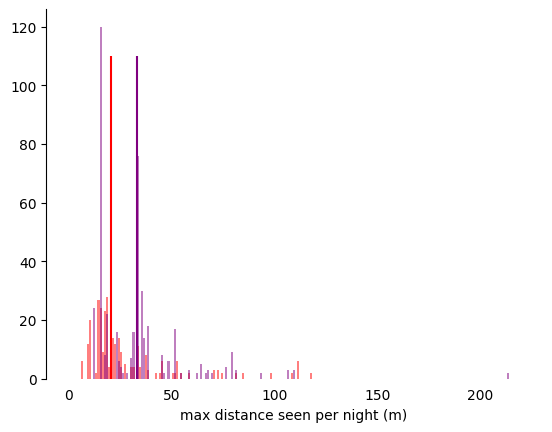

In [ ]:
fig,ax = plt.subplots()
ax.vlines(20.60184823191932,ymin=0,ymax=110,color='red')
ax.vlines(33.09923648786416,ymin=0,ymax=110,color='purple')

ax.hist(mouse_night_df.max_dists[(mouse_night_df.max_dists>0) & (mouse_night_df.GPS_longs<-5.28)],bins=np.arange(0,220,1),color='red',alpha=0.5)
ax.hist(mouse_night_df.max_dists[(mouse_night_df.max_dists>0) & (mouse_night_df.GPS_longs>-5.28)],bins=np.arange(0,220,1),color='purple',alpha=0.5)
ax.spines['bottom'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_ticks_position('none')
ax.set_xlabel('max distance seen per night (m)')
print('obs',np.median(mouse_night_df.max_dists[mouse_night_df.GPS_longs<-5.28]),np.median(mouse_night_df.max_dists[(mouse_night_df.max_dists>0) & (mouse_night_df.GPS_longs<-5.28)]))
print('quarry',np.median(mouse_night_df.max_dists[mouse_night_df.GPS_longs>-5.28]),np.median(mouse_night_df.max_dists[(mouse_night_df.max_dists>0) & (mouse_night_df.GPS_longs>-5.28)]))


quarry 3.7516412900329565 4.8564367150215455
obs 6.017740244875842 7.493321054568282


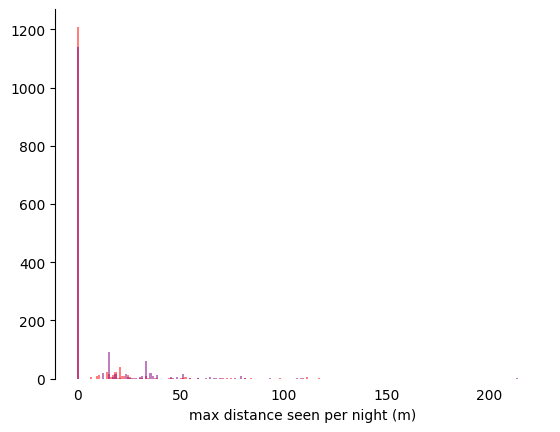

In [ ]:
fig,ax = plt.subplots()
#ax.vlines(20.60184823191932,ymin=0,ymax=110,color='red')
#ax.vlines(33.09923648786416,ymin=0,ymax=110,color='purple')
x=1
ax.hist(mouse_night_df.max_dists[(mouse_night_df.no_checkins>x) & (mouse_night_df.GPS_longs<-5.28)],bins=np.arange(0,220,1),color='red',alpha=0.5)
ax.hist(mouse_night_df.max_dists[(mouse_night_df.no_checkins>x) & (mouse_night_df.GPS_longs>-5.28)],bins=np.arange(0,220,1),color='purple',alpha=0.5)
ax.spines['bottom'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_ticks_position('none')
ax.set_xlabel('max distance seen per night (m)')
print('quarry',np.average(mouse_night_df.max_dists[mouse_night_df.GPS_longs<-5.28]),np.average(mouse_night_df.max_dists[(mouse_night_df.no_checkins>x) & (mouse_night_df.GPS_longs<-5.28)]))
print('obs',np.average(mouse_night_df.max_dists[mouse_night_df.GPS_longs>-5.28]),np.average(mouse_night_df.max_dists[(mouse_night_df.no_checkins>x) & (mouse_night_df.GPS_longs>-5.28)]))


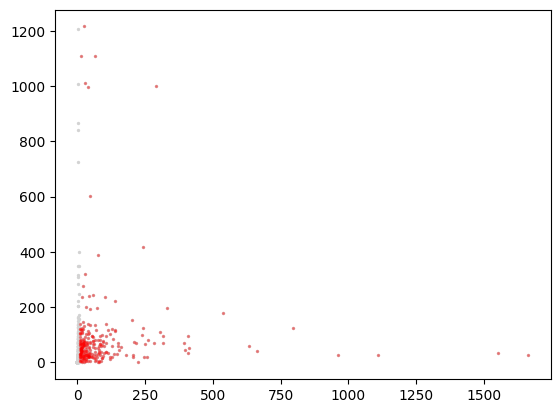

In [ ]:
x=8
plt.scatter(mouse_stat_df.no_checkins,mouse_stat_df.max_dists,s=2,c='lightgray')
plt.scatter(mouse_stat_df.no_checkins[mouse_stat_df.no_checkins>x],mouse_stat_df[mouse_stat_df.no_checkins>x].max_dists,s=2,c='r',alpha=0.3)

Text(0, 0.5, 'number of check ins per mouse')

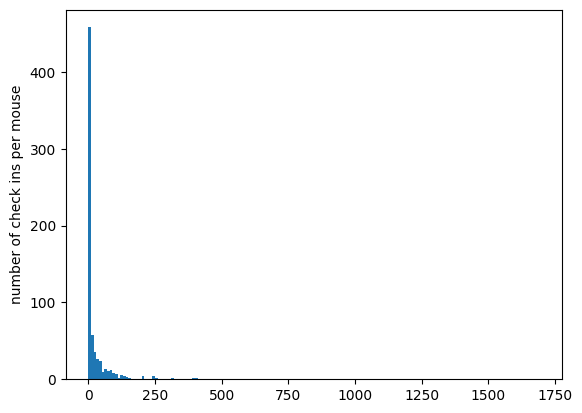

In [ ]:
plt.hist(mouse_stat_df.no_checkins,bins=np.arange(0,1700,10))
plt.ylabel('number of check ins per mouse')

0.0


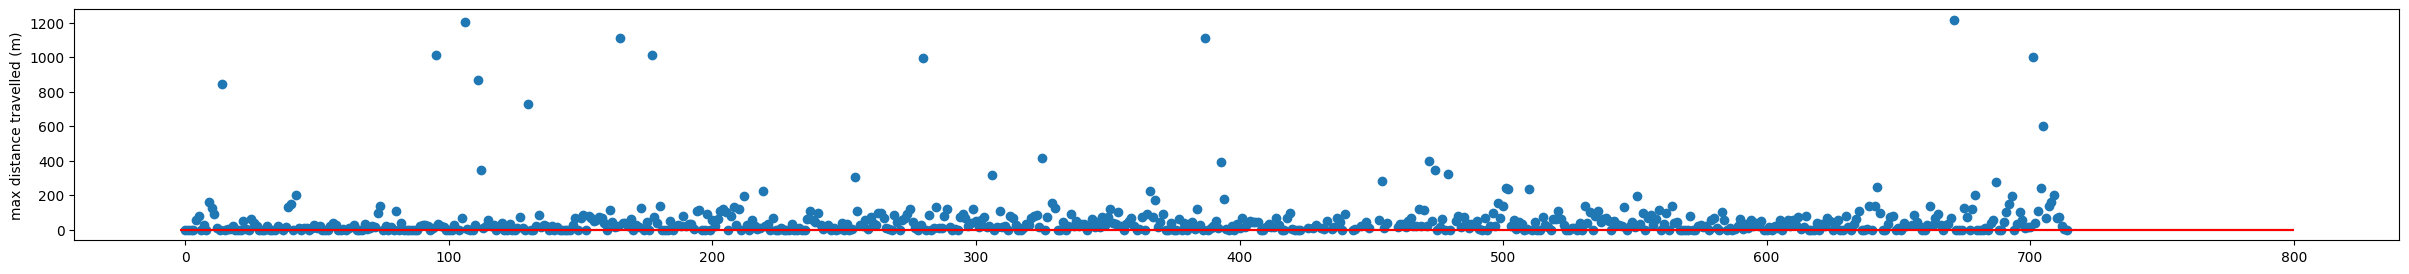

In [ ]:
plt.figure(figsize=(30,3))
plt.hlines(y=0,xmin=-2,xmax=800,color='k')
plt.hlines(y=np.median(max_dists),xmin=-2,xmax=800,color='r')
plt.scatter(mouse_stat_df.index,mouse_stat_df.max_dists)
plt.ylabel('max distance travelled (m)')
#plt.ylim(-5,500)
#plt.yscale('log')
print(np.median(max_dists))

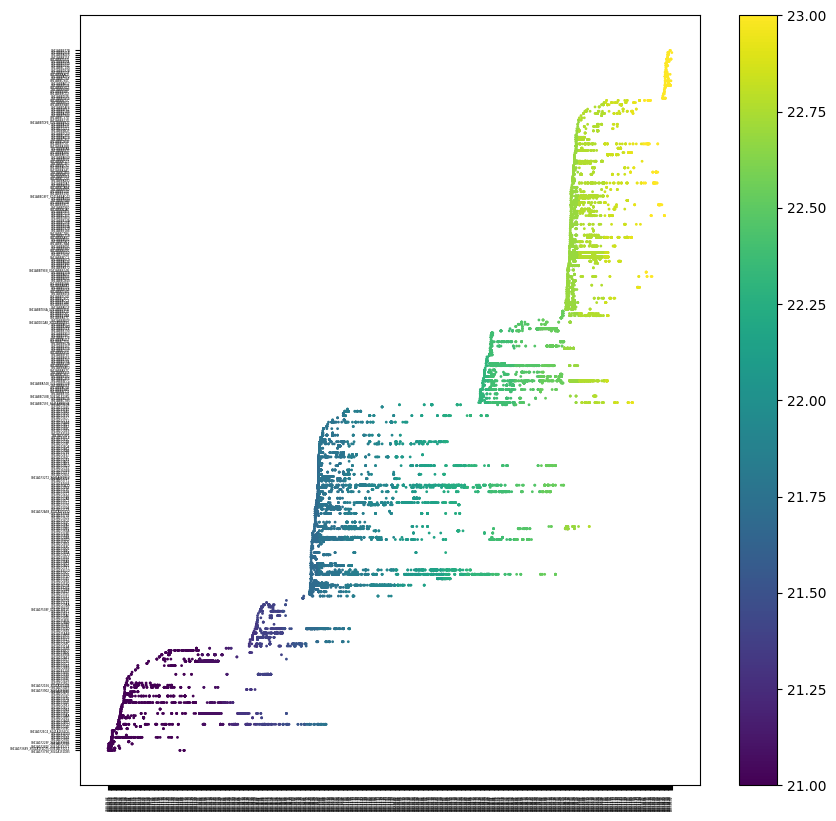

In [ ]:
plt.figure(figsize=(10,10))
plt.xticks(fontsize=2)
plt.yticks(fontsize=2)
plt.tick_params('x',rotation=90)
plt.scatter(capturereads.date_actual,capturereads.mouse_ID,s=1,c=capturereads.yearmonth)
plt.clim(21,23)
plt.colorbar()

### mouse consistency
- for each mouse (y), how many times do we see them (x)

### mouse range per night, week, month
- number of readers/night 
- if 0, dist = NaN, if 1, dist = 0, if >1, calculate

### how 'sticky' are they? when do abrupt/changed movements occur if they do occur?

In [ ]:
# how many mice do we see each night
capturereads.columns

Index(['Tag_IDX', 'location_found_cleaned', 'logger_id_season', 'datetime',
       'LOGGER_ID', 'WIRELESS_ID', 'motion_det', 'tempC', 'hum.', 'AMP1ADC',
       'AMP2ADC', 'batV_L', 'batV_NL', 'int.tempC', 'Tag_ID', 'Err', 'Line',
       'Pdir', 'ext.tempC', 'Comment', 'Day', 'Month', 'Yearx', 'Hours',
       'Minutes', 'Seconds', 'logger_season', 'logger_id', 'location_found',
       'trip', 'Yeary', 'Trapping_date', 'collection_date', 'Season',
       'Trapping_site', 'Trapping_point', 'Garmin_GPS', 'Garmin_ID',
       'GPS_latitude', 'GPS_longitude', 'No_trappingpoints', 'Comments',
       'Merge_GPS_coordinates_by', 'unique_flag_location', 'datetime2',
       'time_difference', 'preceding_same', 'first_value', 'winter_interval',
       'date_actual', 'date', 'mouse_ID', 'tag_id', 'dummy', 'yearmonth'],
      dtype='object')

## WORKING HERE

In [ ]:
mergeddf

,PIT_tag,Year,Month,Day,latitude,longitude,night,LOGGER_ID,nightstr,Minute,arbit_dist
0,X041A1F3790_X041A1F2DB5,2020,9,7,51.699732,-5.274423,7,0843,2020-09-07,219.700000,1.174452
1,X041A1F3689_X041A1F2D75_X041A1F3212,2020,9,7,51.699732,-5.274423,7,0843,2020-09-07,289.050000,1.174452
2,X041A1F3689_X041A1F2D75_X041A1F3212,2020,9,7,51.699732,-5.274423,7,0843,2020-09-07,288.933333,1.174452
3,X041A1F3790_X041A1F2DB5,2020,9,8,51.699732,-5.274423,9,0843,2020-09-09,1186.716667,1.174452
4,X041A1F282F_X041A1F3271,2020,9,8,51.699732,-5.274423,9,0843,2020-09-09,888.950000,1.174452
...,...,...,...,...,...,...,...,...,...,...,...
26952,X041918113E,2019,7,19,51.695598,-5.288075,18,0000,2019-7-18,-1.000000,0.206263
26953,X041A5571C5_X041A556889_X0419181D4A,2019,7,20,51.693820,-5.287067,19,0000,2019-7-19,-1.000000,0.097484
26954,X041A5571F8_X041A5571F8,2019,7,19,51.693948,-5.286606,18,0000,2019-7-18,-1.000000,0.130713
26955,X0XXXXXXXX2,2019,7,15,51.699636,-5.274008,14,0000,2019-7-14,-1.000000,1.192271


In [ ]:
alldates=[]
numofreads=[]
uniquemice=[]
uniqueloggers=[]

for uniquedate in np.unique(mergeddf.nightstr):
    alldates.append(uniquedate)
    numofreads.append(len(mergeddf[mergeddf.nightstr==uniquedate]))
    uniquemice.append(len(np.unique(mergeddf.PIT_tag[mergeddf.nightstr==uniquedate])))
    uniqueloggers.append(len(np.unique(mergeddf.LOGGER_ID[mergeddf.nightstr==uniquedate])))

daily_stats = pd.DataFrame(columns=['unique_date','reads_no','mice_no','logger_no'])
daily_stats.unique_date = alldates
daily_stats.reads_no = numofreads
daily_stats.mice_no = uniquemice
daily_stats.logger_no = uniqueloggers
daily_stats[['yyyy','mm','dd']]=daily_stats.unique_date.str.split('-',expand=True)
daily_stats['yearmo']=(daily_stats.yyyy.astype(int)-2020)*12 + daily_stats.mm.astype(int)

In [ ]:
daily_stats

,unique_date,reads_no,mice_no,logger_no,yyyy,mm,dd,yearmo
0,2019-10-0,52,52,1,2019,10,0,-2
1,2019-4-29,3,3,1,2019,4,29,-8
2,2019-5-0,6,6,1,2019,5,0,-7
3,2019-5-1,10,10,1,2019,5,1,-7
4,2019-7-10,10,10,1,2019,7,10,-5
...,...,...,...,...,...,...,...,...
827,2023-4-25,8,8,1,2023,4,25,40
828,2023-4-28,9,9,1,2023,4,28,40
829,2023-5-0,4,4,1,2023,5,0,41
830,2023-5-1,7,7,1,2023,5,1,41


In [ ]:
numofreads=[]
uniquemice=[]
uniquedates = []

## goal:
#  MAKE A DATA FRAME that's 'long' such that the cols are 
# lat, long, arbit_dist, date (keep all unique dates! I think this can be done with groupby), # of mice per night
# make a plot of y = latitudes, x = date, size = # mice




for idx in mergeddf.index:
    lat=mergeddf.loc[idx,'latitude']
    long=mergeddf.loc[idx,'longitude']
    arbit_dist.append(haversine((minlat,minlong),(lat,long)))
mergeddf['arbit_dist']=arbit_dist

for unique_lat in np.unique(mergeddf.GPS_latitude):
    latdf = mergeddf[mergeddf.latitude==unique_lat].reset_index(drop=True)
    if np.unique(latdf.longitude) > 2:
        print('manually look at {}'.format(unique_lat))
    else:
        uniquedates.append(uniquedate)
        numofreads.append(len(mergeddf[mergeddf.date_actual==uniquedate]))
        uniquemice.append(len(np.unique(mergeddf.mouse_ID[mergeddf.date_actual==uniquedate])))

daily_stats = pd.DataFrame(columns=['unique_date','reads_no','mice_no','logger_no'])
daily_stats.unique_date = alldates
daily_stats.reads_no = numofreads
daily_stats.mice_no = uniquemice
daily_stats.logger_no = uniqueloggers
daily_stats[['yyyy','mm','dd']]=daily_stats.unique_date.str.split('-',expand=True)
daily_stats['yearmo']=(daily_stats.yyyy.astype(int)-2020)*12 + daily_stats.mm.astype(int)

In [ ]:
plt.scatter(daily_stats.reads_no,daily_stats.mice_no,c='k',s=3,alpha=0.2)
plt.xlabel('reads per night')
plt.ylabel('unique mice per night')

NameError: name 'plt' is not defined

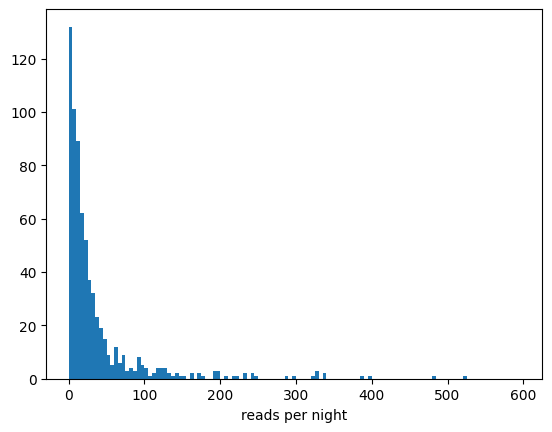

In [ ]:
plt.hist(daily_stats.reads_no,bins=np.arange(0,600,5))
plt.xlabel('reads per night')
plt.show()

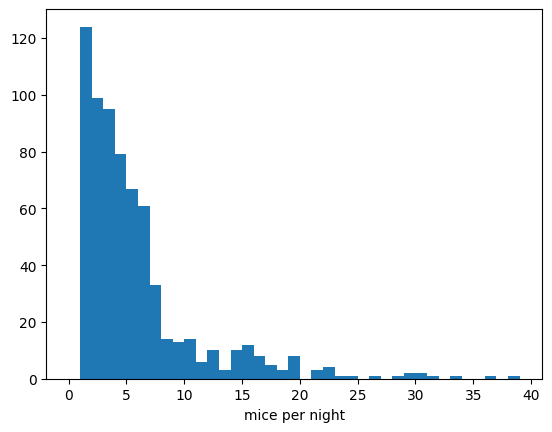

In [ ]:
plt.hist(daily_stats.mice_no,bins=np.arange(0,40,1))
plt.xlabel('mice per night')
plt.show()

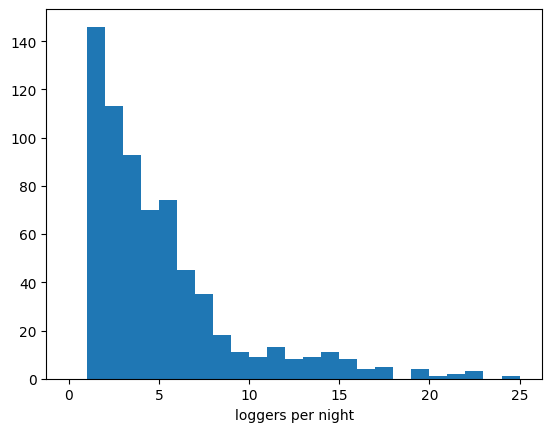

In [ ]:
plt.hist(daily_stats.logger_no,bins=np.arange(0,26,1))
plt.xlabel('loggers per night')
plt.show()

In [ ]:
# for each reader location, plot mice per night max
daily_stats.mice_no

NameError: name 'daily_stats' is not defined

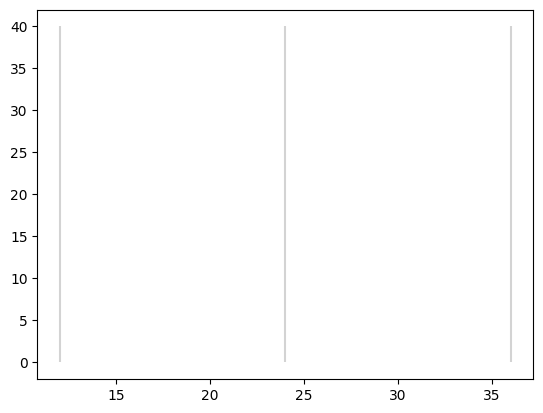

In [11]:
plt.vlines(x=12,ymin=0,ymax=40,color='lightgray')
plt.vlines(x=24,ymin=0,ymax=40,color='lightgray')
plt.vlines(x=36,ymin=0,ymax=40,color='lightgray')
plt.scatter(daily_stats.yearmo,daily_stats.mice_no,c='k',alpha=0.2,s=5)
plt.ylabel('unique mice per night')
plt.xlabel('month')
plt.title('begins 9 = September 2020 \n ends 41 = May 2023 \n vertical lines are December 2020, 2021, 2022')
plt.show()


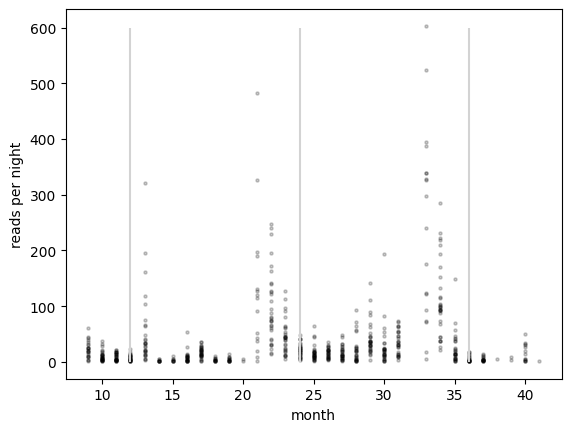

In [297]:
plt.vlines(x=12,ymin=0,ymax=600,color='lightgray')
plt.vlines(x=24,ymin=0,ymax=600,color='lightgray')
plt.vlines(x=36,ymin=0,ymax=600,color='lightgray')
plt.scatter(daily_stats.yearmo,daily_stats.reads_no,c='k',alpha=0.2,s=5)
plt.ylabel('reads per night')
plt.xlabel('month')
plt.show()

In [ ]:
# find 

0

In [72]:
capturereads.columns

Index(['Tag_IDX', 'location_found_cleaned', 'logger_id_season', 'datetime',
       'LOGGER_ID', 'WIRELESS_ID', 'motion_det', 'tempC', 'hum.', 'AMP1ADC',
       'AMP2ADC', 'batV_L', 'batV_NL', 'int.tempC', 'Tag_ID', 'Err', 'Line',
       'Pdir', 'ext.tempC', 'Comment', 'Day', 'Month', 'Yearx', 'Hours',
       'Minutes', 'Seconds', 'logger_season', 'logger_id', 'location_found',
       'trip', 'Yeary', 'Trapping_date', 'collection_date', 'Season',
       'Trapping_site', 'Trapping_point', 'Garmin_GPS', 'Garmin_ID',
       'GPS_latitude', 'GPS_longitude', 'No_trappingpoints', 'Comments',
       'Merge_GPS_coordinates_by', 'unique_flag_location', 'datetime2',
       'time_difference', 'preceding_same', 'first_value', 'winter_interval',
       'date_actual', 'date', 'mouse_ID', 'tag_id', 'dummy', 'arbit_dist',
       'yearmonth', 'night', 'nightstr'],
      dtype='object')

In [43]:
subcapture.columns

Index(['identifier', 'X', 'unique_id', 'animal_ID', 'PIT_tag', 'PIT_detected',
       'PIT_tagging_occurred', 'trap_number', 'flag', 'location',
       'location_notes', 'site', 'collection_date', 'released',
       'PIT_tagging_comments', 'trapping_date', 'Garmin_GPS', 'PIT_tag_nonmod',
       'mouse_id', 'trap_peanuts', 'trap_comments', 'datetrap', 'Year',
       'Month', 'Day', 'year_month', 'latitude', 'longitude'],
      dtype='object')

In [107]:
# exploring subcapture
print([val for val in subcapture.animal_ID if 'nan' not in val])
print([val for val in subcapture.PIT_tag if 'nan' not in val])
print([val for val in subcapture.PIT_detected if val!='nan'])
print(np.unique(subcapture.PIT_tagging_occurred))

['SK0054', 'SK0062', 'SK0052', 'Sk0082', 'SK0072', 'SK0109', 'Sk0108', 'SK0083', 'SK0071', 'Sk0106', 'Sk0103', 'Sk0100', 'Sk0085', 'SK0064', 'SK0087', 'Sk0079', 'SK0073', 'SK0080', 'Sk0094', 'SK0026', 'SK0053', 'SK0102', 'Sk0092', 'SK0065', 'SK0029', 'SK0110', 'SK0060', 'SK0095', 'SK0063', 'SK0112', 'SK0056', 'SK0059', 'SK0055', 'SK0069', 'SK0097', 'SK0028', 'Sk0089', 'SK0066', 'SK0046', 'SK0074', 'SK0090', 'Sk0111', 'Left ear x1, looks like 4. Nothing in right ear', 'SK0076', 'SK0050', 'SK0057', 'SK0068', 'SK0044', 'SK0107', 'Sk0084', 'Sk0096', 'SK0078', 'SK0061', 'SK0046?', 'SK0088', '?', 'SK0067', 'Sk0091', 'Recapture but has lost tag? Right ear 20?', 'SK0031', 'SK0013', 'SK0005', 'SK0010', 'SK0013', 'SK0007', 'SK0022', 'SK0045', 'SK0016', 'SK0101', 'SK0018 Right 10', 'SK0008', 'SK0019', 'SK0011', 'SK0041', 'SK0043', 'SK0007', 'SK0028', 'SK0039', 'SK0036', 'SK0046', 'SK0023', 'SK0029', 'SK0002', 'SK0014', 'SK0009', 'Right x3', 'SK0001', 'SK0033', 'SK0015', 'SK0035', 'Left ear 2?', '

In [113]:
np.unique(subcapture.PIT_tag[subcapture.PIT_tag != 'nan'])

array(['X041917E004', 'X041917E031', 'X041917E04E', 'X041917E062',
       'X041917E15B', 'X041917E1B8', 'X041917E205',
       'X041917E211_X041917E63B', 'X041917E25D', 'X041917E2C4',
       'X041917E386', 'X041917E38A', 'X041917E45E', 'X041917E548',
       'X041917E55B', 'X041917E6C9', 'X041917E731', 'X041917E7BD',
       'X041917E9C7', 'X041917E9C8', 'X041917E9D6', 'X041917E9DB',
       'X041917EAEC_X041917FE84', 'X041917ECA9', 'X041917ECB4',
       'X041917EE77', 'X041917EE7F', 'X041917F050', 'X041917F05F',
       'X041917F0FF', 'X041917F18B', 'X041917F18E', 'X041917F196',
       'X041917F237', 'X041917F2E8', 'X041917F4E3', 'X041917F581',
       'X041917F6DD', 'X041917F791', 'X041917F8E5', 'X041917F99D',
       'X041917FA51', 'X041917FB00_X041A1F32B8', 'X041917FB03',
       'X041917FBAD', 'X041917FD16', 'X041917FE81', 'X041917FF41',
       'X041917FF44', 'X04191800AB', 'X04191800B1', 'X0419180171',
       'X0419180216', 'X04191802D3_X0419183575', 'X04191802DA',
       'X04191802E4', 

In [133]:
recaptures=[]
for val in np.unique(subcapture.PIT_tag):
    recaptures.append(len(subcapture[subcapture.PIT_tag==val]))
    print(val,recaptures[-1])

X041917E004 1
X041917E031 1
X041917E04E 1
X041917E062 1
X041917E15B 3
X041917E1B8 3
X041917E205 1
X041917E211_X041917E63B 2
X041917E25D 1
X041917E2C4 3
X041917E386 2
X041917E38A 2
X041917E45E 2
X041917E548 1
X041917E55B 4
X041917E6C9 1
X041917E731 2
X041917E7BD 2
X041917E9C7 2
X041917E9C8 1
X041917E9D6 1
X041917E9DB 1
X041917EAEC_X041917FE84 3
X041917ECA9 3
X041917ECB4 1
X041917EE77 3
X041917EE7F 2
X041917F050 2
X041917F05F 1
X041917F0FF 1
X041917F18B 1
X041917F18E 3
X041917F196 1
X041917F237 1
X041917F2E8 1
X041917F4E3 2
X041917F581 2
X041917F6DD 1
X041917F791 2
X041917F8E5 5
X041917F99D 3
X041917FA51 1
X041917FB00_X041A1F32B8 3
X041917FB03 2
X041917FBAD 1
X041917FD16 2
X041917FE81 2
X041917FF41 1
X041917FF44 2
X04191800AB 4
X04191800B1 3
X0419180171 3
X0419180216 1
X04191802D3_X0419183575 2
X04191802DA 1
X04191802E4 3
X04191804FD 2
X0419180676 3
X04191807F6 1
X04191808AC 2
X041918095E 3
X0419180962 1
X0419180967 3
X0419180AC6 3
X0419180AD8 2
X0419180C34 1
X0419180E61 1
X0419180E65 2


In [155]:
print(subcapture.latitude[subcapture.flag=='1']) # flags can be at diff lat/long
subcapture.latitude[subcapture.trap_number=='42'] # trap numbers can be at diff lat/long
# so I'm using lat/long

84     51.699737
124    51.698597
548    51.699737
549    51.699737
550    51.699737
551    51.699737
737    51.699737
Name: latitude, dtype: object


202          nan
313    51.699693
574    51.701858
583    51.699634
Name: latitude, dtype: object

Text(0.5, 1.0, '33.84615384615385% were recaptured at least once')

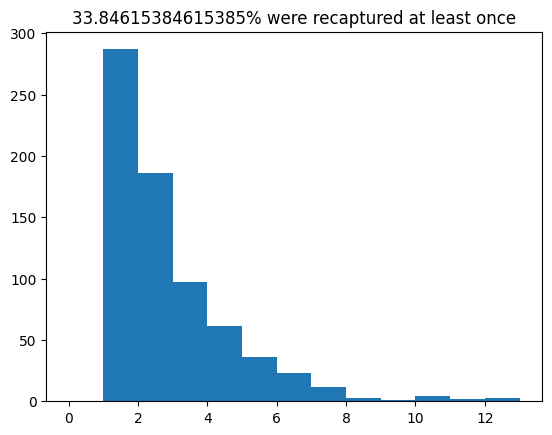

In [142]:
sumofvals=np.sum([473.,  97.,  61.,  36.,  23.,  15.,   1.,   4.,   2.,   3.])
plt.hist(recaptures,bins=np.arange(0,14,1))
plt.title('{}% were recaptured at least once'.format((sumofvals-473)/(sumofvals/100)))

In [122]:
subcapture[subcapture.PIT_tag=='X041ABB99BC']

,identifier,X,unique_id,animal_ID,PIT_tag,PIT_detected,PIT_tagging_occurred,trap_number,flag,location,...,mouse_id,trap_peanuts,trap_comments,datetrap,Year,Month,Day,year_month,latitude,longitude
1405,213_2022_Spring,1243,5d0d8469-09b4-4f14-bf41-c280df39dac9,SK0596,X041ABB99BC,0.0,now,406,213,quarry,...,X041ABB99BC,3.9,,406 2022-04-24,2022,4,24,2022_04,51.695261,-5.288027
1406,214_2022_Summer,1386,244623d6-db02-4f4b-bc4c-262287c8bc2f,nan,X041ABB99BC,1.0,was,936,214,quarry,...,X041ABB99BC,3.9,,936 2022-07-26,2022,7,26,2022_07,51.695207,-5.287996
1407,216_2022_Autumn,1664,ba96bd8e-9e0e-40f2-8ae9-bc17f991f1a7,nan,X041ABB99BC,1.0,was,627,216,quarry,...,X041ABB99BC,1.8,,627 2022-09-23,2022,9,23,2022_09,51.695209,-5.28806
1408,218_2022_Autumn,1568,8a472831-b5c9-40b7-a997-d03266cde24a,nan,X041ABB99BC,1.0,was,C13,218,quarry,...,X041ABB99BC,0.0,,C13 2022-09-17,2022,9,17,2022_09,51.695182,-5.288038
1409,218_2022_Autumn,1703,c4cc0c0d-133b-452f-aef3-fecccc9131d2,nan,X041ABB99BC,1.0,was,Z007,218,quarry,...,X041ABB99BC,0.0,,Z007 2022-09-24,2022,9,24,2022_09,51.695182,-5.288038
1410,221_2022_Autumn,1745,18279ad0-5147-11ed-a0f4-4703a610863d,SK0,X041ABB99BC,1.0,nan,C30,221,quarry,...,X041ABB99BC,nan,recap released immediately due to heavy work l...,C30 2022-09-25,2022,9,25,2022_09,51.695186,-5.28812
1411,225_2022_Autumn,1511,62943c75-07bb-4086-bb92-c61515790297,nan,X041ABB99BC,1.0,was,504,225,quarry,...,X041ABB99BC,1.9,,504 2022-09-15,2022,9,15,2022_09,51.695165,-5.288179
1412,250_2022_Autumn,1541,8d96694a-ba37-4b5c-826e-7512a2382bb4,nan,X041ABB99BC,1.0,was,439,250,quarry,...,X041ABB99BC,0.88,,439 2022-09-16,2022,9,16,2022_09,51.69512,-5.287717
